<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_LAB1/Experiencia_5_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiencia 5 — Sistema de monitoreo pasivo de fauna
## Inteligencia Computacional — IC415 | RA1 Laboratorio N° 1

### Contexto del problema

La Administración de Parques Nacionales, en colaboración con una universidad regional, está desarrollando un sistema de monitoreo pasivo de fauna en reservas de la región de Misiones. El monitoreo tradicional requiere presencia humana permanente (costoso, invasivo para la fauna y logísticamente complejo en zonas de difícil acceso). La alternativa es desplegar grabadores de audio autónomos que operen durante semanas y luego procesar los registros automáticamente.
El objetivo es identificar de forma automática la presencia de especies o grupos de interés en los registros de audio. Las "firmas" acústicas de interés incluyen especies de fauna nativa cuya presencia o ausencia es indicador del estado de salud del ecosistema. El sistema debe poder procesar horas de audio y producir un log con estampas de tiempo de detección (herramienta de trabajo real para biólogos y guardaparques).

---

### Estructura del notebook

1. Análisis Exploratorio de Datos (EDA)
2. Pipeline de Preprocesamiento
3. Entrenamiento y Comparativa de Modelos
4. Evaluación del Modelo Seleccionado y Conclusiones


## Librerías y configuración global

In [18]:
# ─── Librerías ───
import sys, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV

# Sklearn — modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Sklearn — métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)

# Librerías básicas para audio
import scipy.io.wavfile as waves
from scipy.io import wavfile
from IPython.display import Audio

# Imbalanced learning
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
print("Librerías importadas correctamente.")


Librerías importadas correctamente.


---
## 1. Análisis Exploratorio de Datos (EDA)



### 1.1 Carga del dataset

In [19]:
# The audio samples appear to be already available in the runtime at '/content/Lab1_Enunciado5_muestras/'.
# Skipping wget and unzip commands and directly setting the directory path.

directorio = '/content/Lab1_Enunciado5_muestras/'
# Ojo: A veces al descomprimir se crea una subcarpeta, si te da error revisá la ruta.
# arch_audio = [f for f in os.listdir(directorio) if f.endswith('.wav')]
# Si el zip tenía una carpeta adentro, capaz necesites: directorio = 'muestras_audio/muestras_audio/'

archivos = [f for f in os.listdir(directorio) if f.endswith('.wav')]

datos_energia = []
ejemplos_grafico = {} # Guardaremos 1 ejemplo de C, 1 de G y 1 de L para graficarlos luego

print(f"Se encontraron {len(archivos)} archivos .wav. Procesando...")

for archivo in archivos:
    # 1. Extraer etiqueta desde el nombre (ej: "C_01.wav" -> "C")
    clase = archivo.split('_')[0]
    ruta_completa = os.path.join(directorio, archivo)

    # 2. Cargar el archivo WAV
    fs, audio = wavfile.read(ruta_completa)

    # Asegurarnos de que sea mono (por si acaso alguno vino stereo)
    if len(audio.shape) > 1:
        audio = audio[:, 0]

    # Guardar el primer representante de cada clase para el gráfico de la Celda 3
    if clase not in ejemplos_grafico:
        ejemplos_grafico[clase] = (fs, audio)

    # 3. Calcular la FFT (Transformada Rápida de Fourier)
    N = len(audio)
    fft_espectro = np.fft.rfft(audio)       # rfft es ideal para señales reales (mono)
    frecuencias = np.fft.rfftfreq(N, 1/fs)  # Vector de frecuencias (Eje X)

    # Magnitud normalizada al cuadrado = Energía en esa frecuencia
    energia_espectro = (np.abs(fft_espectro) / N) ** 2

    # 4. Calcular energía en las 3 bandas específicas
    # Encontramos los índices del array que caen dentro de las bandas
    idx_baja = np.where((frecuencias >= 1000) & (frecuencias <= 3000))[0]
    idx_media = np.where((frecuencias >= 4000) & (frecuencias <= 6000))[0]
    idx_alta = np.where((frecuencias >= 7000) & (frecuencias <= 10000))[0]

    # Sumamos la energía de esos índices
    banda_baja = np.sum(energia_espectro[idx_baja])
    banda_media = np.sum(energia_espectro[idx_media])
    banda_alta = np.sum(energia_espectro[idx_alta])

    # 5. Guardar en la lista
    datos_energia.append({
        'banda_baja': banda_baja,
        'banda_media': banda_media,
        'banda_alta': banda_alta,
        'clase': clase
    })

# Armar el DataFrame final
df_audio = pd.DataFrame(datos_energia)

print("\n--- DATAFRAME GENERADO EXITOSAMENTE ---")
display(df_audio.head())
print("\nDistribución de clases:")
print(df_audio['clase'].value_counts())

Se encontraron 52 archivos .wav. Procesando...

--- DATAFRAME GENERADO EXITOSAMENTE ---


,banda_baja,banda_media,banda_alta,clase
0,7.320806e+01,8.575933e+06,9.004816,G
1,3.346094e+02,8.511087e+06,443557.197122,GL
2,8.081700e+06,1.342609e+02,72.102838,C
3,2.364227e-01,7.073814e-01,283333.091164,L
4,5.417112e+01,8.916581e+06,189.525156,G



Distribución de clases:
clase
G     14
C     14
L     14
GC     4
GL     3
CL     3
Name: count, dtype: int64


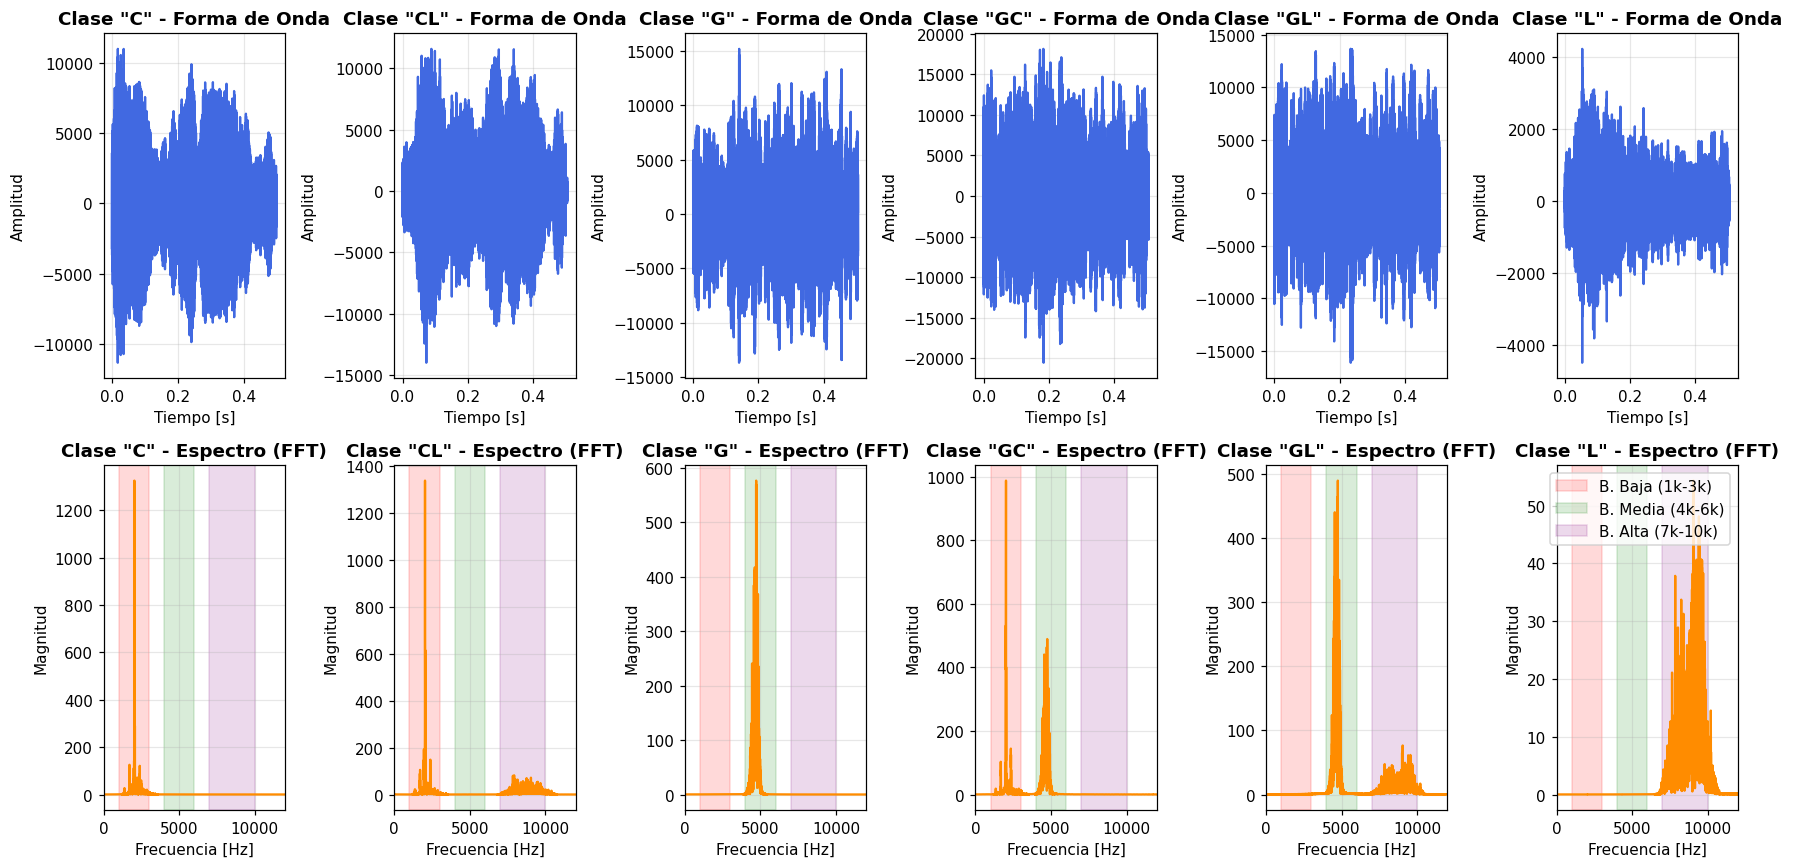

In [20]:
# ==========================================
# GRÁFICOS (FORMA DE ONDA Y FFT)
# ==========================================
# Ordenamos las clases alfabéticamente (C, G, L)
clases_ordenadas = sorted(list(ejemplos_grafico.keys()))

# Armamos un grid de 2 filas (Onda, FFT) y 3 columnas (C, G, L)
fig, axes = plt.subplots(2, len(clases_ordenadas), figsize=(16, 8))

for i, clase in enumerate(clases_ordenadas):
    fs, audio = ejemplos_grafico[clase]
    tiempo = np.arange(len(audio)) / fs

    # Calculamos la FFT para el gráfico
    N = len(audio)
    frecuencias = np.fft.rfftfreq(N, 1/fs)
    magnitud = np.abs(np.fft.rfft(audio)) / N

    # --- FILA 0: Forma de Onda en el Tiempo ---
    axes[0, i].plot(tiempo, audio, color='royalblue')
    axes[0, i].set_title(f'Clase "{clase}" - Forma de Onda', fontweight='bold')
    axes[0, i].set_xlabel('Tiempo [s]')
    axes[0, i].set_ylabel('Amplitud')
    axes[0, i].grid(True, alpha=0.3)

    # --- FILA 1: Espectro de Frecuencias (FFT) ---
    axes[1, i].plot(frecuencias, magnitud, color='darkorange')
    axes[1, i].set_title(f'Clase "{clase}" - Espectro (FFT)', fontweight='bold')
    axes[1, i].set_xlabel('Frecuencia [Hz]')
    axes[1, i].set_ylabel('Magnitud')
    # Limitamos el eje X a 12kHz (Teorema de Nyquist para 24kHz)
    axes[1, i].set_xlim(0, 12000)
    axes[1, i].grid(True, alpha=0.3)

    # Sombreamos visualmente las bandas que usamos para extraer la energía
    axes[1, i].axvspan(1000, 3000, color='red', alpha=0.15, label='B. Baja (1k-3k)')
    axes[1, i].axvspan(4000, 6000, color='green', alpha=0.15, label='B. Media (4k-6k)')
    axes[1, i].axvspan(7000, 10000, color='purple', alpha=0.15, label='B. Alta (7k-10k)')

# Ponemos la leyenda de las bandas sombreadas en el último gráfico
axes[1, -1].legend()

plt.tight_layout()
plt.show()

---
## 2. Pipeline de Preprocesamiento

---

### Definición de la estrategia de evaluación: tipos de error y métricas priorizadas



### 2.1 División train/test — PRIMER PASO

### 2.2 Encoding de variables categóricas


---
## 3. Entrenamiento y Comparativa de Modelos


---
## 4. Evaluación del Modelo Seleccionado y Conclusiones



### 4.1 Matriz de confusión

### 4.5 Conclusión

